# Introduction to Confidence Intervals

### Objective:

- Understand what a Confidence Interval (CI) is in simple terms.

- Learn why CIs are useful in data analytics and decision-making.

Note: Use the `“Compare Answer”` toggle to check your responses. Your answer doesn’t need to be exact.


----

# Case Study: Estimating the Median Income of a City

Scenario:
You are a data analyst at a consulting firm, and your client is interested in estimating the median household income of a city. 

The distribution of incomes is often skewed, with a few very high incomes pulling the mean upward. 

Therefore, using the median as a measure of central tendency is more appropriate than using the mean.

Because the data is skewed, we cannot assume a normal distribution, so we need to approach the problem differently when calculating confidence intervals.

## What Data type are you working with?




Your answer here:

<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Data Type: Continuous (Annual income is measured in dollars, which can take any value within a range)</p>
  
</details>

## Identify the Analytical Question:

Your answer here:



<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>What is the 95% confidence interval for the median income of the residents?</p>
  
</details>

## Calculate the Descriptive stats

In [9]:
# Load the dataset
df = pd.read_csv('data/income_data.csv')

# Calculate Descriptive Statistics
sample_mean = df['AnnualIncome'].mean()
sample_std = df['AnnualIncome'].std()
sample_median = df['AnnualIncome'].median()
n = len(df)

print(f"Sample Mean: ${sample_mean:.2f}")
print(f"Sample Standard Deviation: ${sample_std:.2f}")
print(f"Sample Median: ${sample_median:.2f}")


Sample Mean: $48625.30
Sample Standard Deviation: $48625.49
Sample Median: $34339.13


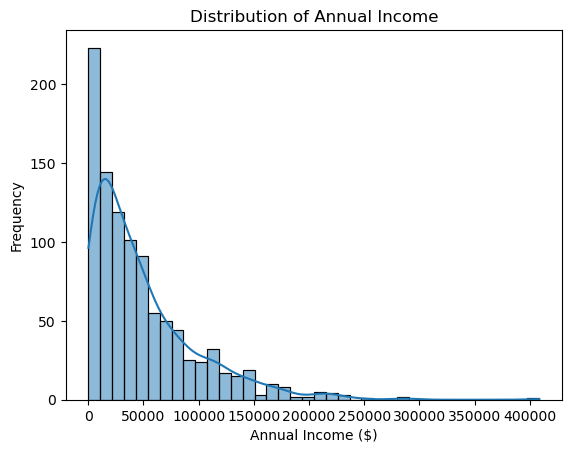

In [10]:
# Visualize the data
sns.histplot(df['AnnualIncome'], kde=True)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Frequency")
plt.show()


## Interpret the Graph and Descriptive Statistics:



Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Graph: The histogram is likely to be right-skewed, indicating that a few individuals have very high incomes compared to the majority.
  
Descriptive Statistics: The mean is likely higher than the median due to the skewness. This suggests that the median is a better measure of central tendency for this data.</p>
  
</details>

## Check if Population Parameters are Known


Your answer here:


<details>
  <summary>Compare Answer</summary>
  <p>
  For skewed data, things like mean and standard deviation don’t tell the full story.

  In this case, what we really care about is the median, since it better represents the “typical” household income.

  Unlike the mean under normality, the median does not have a simple formula for its confidence interval.

  That’s why we turn to bootstrapping — a flexible method that doesn’t require us to assume a normal distribution.

</p>
  
</details>

----

## About the Dataset

This dataset contains 1000 household incomes that follow a **right-skewed distribution**. 

Most incomes are clustered towards the lower end, but there are some very high incomes that create a long tail on the right.

This type of distribution is common for income data.

Since the data is not normally distributed, we will focus on estimating the **median** income rather than the mean. 

Additionally, we will use **bootstrapping** to calculate the confidence interval for the median.


### Why Bootstrapping?

Since the income data is not normally distributed, traditional methods like the Z-distribution aren't appropriate. 

Bootstrapping allows us to estimate the confidence interval without assuming normality, making it a versatile tool in non-parametric settings.

Bootstrapping is a resampling technique that involves repeatedly drawing samples (with replacement) from a dataset to estimate a population parameter (like the mean, median, standard deviation, etc.) and its confidence interval.

The key idea behind bootstrapping is to treat the sample you have as if it were a representation of the population. By resampling from this sample, you can simulate what it would be like to draw new samples from the population without having access to the full population.

How Does Bootstrapping Work?
Bootstrapping involves three main steps:

1. Resample with Replacement
Resampling with Replacement: This means that when you draw a sample from the data, you put the sampled observation back into the data so that it can be selected again in subsequent draws. This allows each resampled dataset to be different from the others.

You create multiple new "bootstrap samples" from the original dataset. The size of each bootstrap sample is usually the same as the original sample.

2. Calculate the Statistic of Interest
For each bootstrap sample, you calculate the statistic you are interested in (e.g., the median, mean, or variance). This gives you a distribution of the statistic based on the resampled data.

3. Estimate the Confidence Interval
Once you have the distribution of your statistic from all the bootstrap samples, you can estimate the confidence interval by finding the appropriate percentiles of this distribution (e.g., the 2.5th and 97.5th percentiles for a 95% confidence interval).

In [12]:
# Step 1: Calculate the sample median
sample_median = df['AnnualIncome'].median()
print(f"Sample Median Income: ${sample_median:.2f}")

# Step 2: Define a bootstrapping function to calculate the CI
def bootstrap_ci(data, num_bootstrap=1000, confidence_level=0.95):
    # Create bootstrap samples and calculate the median for each sample
    bootstrapped_medians = []
    n = len(data)
    for _ in range(num_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_medians.append(np.median(sample))
    
    # Calculate the lower and upper bounds of the confidence interval
    lower_bound = np.percentile(bootstrapped_medians, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrapped_medians, (1 + confidence_level) / 2 * 100)
    return lower_bound, upper_bound

# Step 3: Calculate the 95% confidence interval using bootstrapping
ci_lower, ci_upper = bootstrap_ci(df['AnnualIncome'], num_bootstrap=1000, confidence_level=0.95)
print(f"95% Confidence Interval for the Median Income: (${ci_lower:.2f}, ${ci_upper:.2f})")


Sample Median Income: $34339.13
95% Confidence Interval for the Median Income: ($30645.29, $37090.04)


### Interpretation of Results

The sample median income is about $34,339.

The 95% confidence interval for the city’s true median income is:
($30,645, $37,090).

What does this mean?

If we were to take many different random samples from the city and build a 95% CI each time, about 95 out of 100 of those intervals would contain the true population median.

For our analysis, we can be fairly confident the typical household earns between $30K and $37K.

### Application to Decision-Making

- **Scenario 1:** If the city government is planning financial aid programs for households earning below the median income, this confidence interval gives them a range to target. 
- **Scenario 2:** If a new policy aims to increase the median income, understanding the current range helps assess the policy's impact over time.




In [13]:
# Experiment with different sample sizes or bootstrap iterations
sample_sizes = [100, 500, 1000]
for size in sample_sizes:
    ci_lower, ci_upper = bootstrap_ci(df['AnnualIncome'].sample(size), num_bootstrap=1000, confidence_level=0.95)
    print(f"95% CI for Median Income with sample size {size}: (${ci_lower:.2f}, ${ci_upper:.2f})")


95% CI for Median Income with sample size 100: ($20945.81, $42466.71)
95% CI for Median Income with sample size 500: ($28831.08, $39812.63)
95% CI for Median Income with sample size 1000: ($30407.96, $36958.95)


Key Points:

- Non-normal data often arises in real-world scenarios (e.g., income, wait times, or any data with skewness).

- Median is a better measure of central tendency for skewed data.

- Bootstrapping is a flexible, non-parametric method that can be used to calculate confidence intervals without assuming normality.

- This approach is particularly useful when the sample size is small, or the distribution is heavily skewed.

-----

# So why NOT Bootstrap all the time?

You could, but it’s not always necessary — and sometimes it’s less efficient.

- When distributions are well understood (e.g., normal data, known parameters):

     - Using formulas (Z or t) is faster and more exact than simulating thousands of resamples.

     - For example: tablet dosages with known mean & std → Z-formula is the clean choice.

- When distributions are unknown, skewed, or weird:

    - Bootstrapping shines because it doesn’t assume anything about shape.

    - It lets the data “speak for itself.”

- Tradeoff:

    - Bootstrapping takes more computation. Not a big deal today with modern machines, but it can still be overkill if a simple formula works.

    - Think of it like using a calculator: sometimes you just need 2+2=4 (simple formula), not a full simulation.